# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 4. Modelos alternativos
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Modelo 3 CNN 1D (Convolución unidimensional)

**CNN 1D (Convolución unidimensional)**

   Las redes convolucionales 1D aplican filtros sobre la dimensión temporal, extrayendo patrones locales de movimiento.  
   Este enfoque es útil cuando existen transiciones cortas y consistentes en el tiempo (por ejemplo, la rotación de un dedo o un cambio breve de posición).  


## Librerías

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score

2025-10-19 22:39:45.285157: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-19 22:39:45.299048: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760935185.314988   25186 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760935185.319888   25186 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760935185.332581   25186 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Carga de Datos

In [ ]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /mnt/d/Code/MNA/lsm/TC5035-PI-E51/Avance4/processed_data_pipeline 
VIDEOS DIRECTORY: /mnt/d/Code/MNA/lsm/TC5035-PI-E51/Avance4/data/videos


In [3]:
# --- Cargar los Datos Preprocesados ---
print("--- Cargando datos preprocesados ---")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, "X_test.npy"))
y_train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_test.csv"))
y_train_labels = y_train_df['class'].values
y_test_labels = y_test_df['class'].values

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")

# --- Codificar las Etiquetas ---
print("\n--- Codificando las etiquetas ---")
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train_labels, y_test_labels])
label_encoder.fit(all_labels)
y_train_encoded = label_encoder.transform(y_train_labels)
y_test_encoded = label_encoder.transform(y_test_labels)
num_classes = len(label_encoder.classes_)

# Dividimos los datos de entrenamiento para crear un conjunto de validación
# Usaremos el 15% de los datos de entrenamiento para validación
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(
    X_train, 
    y_train_encoded, 
    test_size=0.15, # 15% para validación
    random_state=42,
    stratify=y_train_encoded # Mantiene la proporción de clases
)

y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_val_categorical = to_categorical(y_val_encoded)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)
print(f"Número de clases únicas: {num_classes}")

--- Cargando datos preprocesados ---
Forma de X_train: (164, 150, 5)
Forma de X_test: (41, 150, 5)

--- Codificando las etiquetas ---
Número de clases únicas: 4


## Modelo 3 CNN1 (Convolución unidimensional)

In [4]:
# --- Construir el Modelo CNN1D ---
print("\n--- Construyendo la arquitectura del modelo CNN1D ---")
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(y_train_categorical.shape[1], activation='softmax')
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


--- Construyendo la arquitectura del modelo CNN1D ---


/home/raven/miniconda3/envs/lsm/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760935188.103661   25186 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 148, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 74, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 72, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       460,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,032 (1.86 MB)

 Trainable params: 487,032 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [5]:
# --- Entrenamiento del Modelo ---
print("\n--- Entrenando el modelo ---")
history = model.fit(X_train, y_train_categorical,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_val, y_val_categorical),
                    verbose=1)


--- Entrenando el modelo ---
Epoch 1/50


I0000 00:00:1760935196.423485   25317 service.cc:152] XLA service 0x71e69401b570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760935196.423513   25317 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-10-19 22:39:56.454101: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760935196.593843   25317 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-10-19 22:39:59.577757: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv %cudnn-conv.7 = (f32[64,128,1,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,1,74]{3,2,1,0} %bitcast.4860, f32[128,32,1,72]{3,2,1,0} %bitcast.4867), window={size=1x72}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/seque

1/5 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.2812 - loss: 1.4789

I0000 00:00:1760935200.945608   25317 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.5755 - loss: 0.9768 - val_accuracy: 0.9200 - val_loss: 0.2648
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9209 - loss: 0.2614 - val_accuracy: 0.9600 - val_loss: 0.1522
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9496 - loss: 0.2095 - val_accuracy: 1.0000 - val_loss: 0.0456
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9568 - loss: 0.1185 - val_accuracy: 1.0000 - val_loss: 0.0213
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9928 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 0.0280
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9712 - loss: 0.0749 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0241 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 9/50

## Resultado

In [6]:
# --- Evaluar y Visualizar los Resultados ---
print("\n--- Evaluando el modelo con métricas detalladas ---")

# Realizar predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
# Convertir las probabilidades a etiquetas de clase predichas (la de mayor probabilidad)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)


--- Evaluando el modelo con métricas detalladas ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step


In [7]:
# Generar y mostrar el Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
# Reporte: precisión, recall y f1-score para cada clase.
report = classification_report(y_test_encoded, y_pred_encoded, target_names=label_encoder.classes_)
print(report)

# Accuracy (Precisión Global)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"La precisión (accuracy) del modelo es: {accuracy:.2f}")

# Recall
recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El recall (weighted) del modelo es: {recall:.2f}")

# F1-score
f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El F1-score (weighted) del modelo es: {f1:.2f}")


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Abrir       1.00      1.00      1.00        10
      Avión       1.00      1.00      1.00        10
      Borrar       1.00      1.00      1.00        11
          Tu       1.00      1.00      1.00        10

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

La precisión (accuracy) del modelo es: 1.00
El recall (weighted) del modelo es: 1.00
El F1-score (weighted) del modelo es: 1.00



--- Matriz de Confusión ---


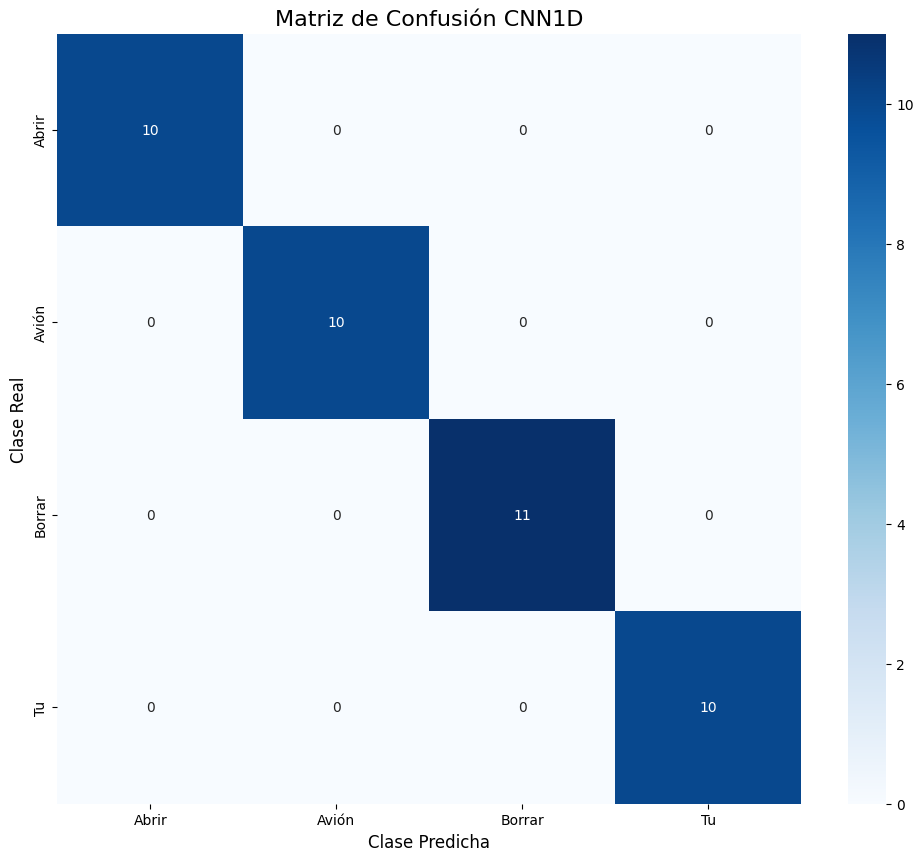

In [8]:
# Generar y mostrar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión CNN1D', fontsize=16)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.show()


--- Gráfica de precisión y pérdida durante el entrenamiento ---


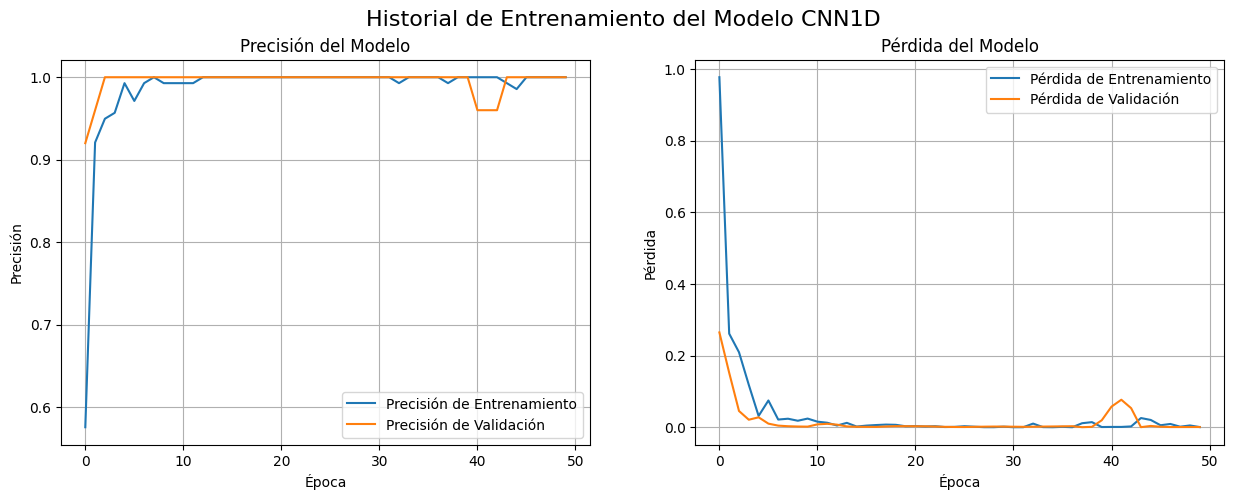


Entrenamiento completado!


In [9]:
# Graficar la precisión y la pérdida durante el entrenamiento
print("\n--- Gráfica de precisión y pérdida durante el entrenamiento ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Gráfica de Precisión
ax1.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Precisión de Validación')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)
# Gráfica de Pérdida
ax2.plot(history.history['loss'], label='Pérdida de Entrenamiento')
ax2.plot(history.history['val_loss'], label='Pérdida de Validación')
ax2.set_title('Pérdida del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)
plt.suptitle('Historial de Entrenamiento del Modelo CNN1D', fontsize=16)
plt.show()

print("\nEntrenamiento completado!")